# 06 — Three-way: behaviour × trajectory × EEG

Lab \(n = 18\), person-level \(D_i\). Partial Spearman on ranks: behaviour ~ EEG | trajectory, behaviour ~ trajectory | EEG, trajectory ~ EEG | behaviour. Primary behaviour (4) × headline EEG (2) × primary trajectory (5) × three planned contrasts = 360 tests. Association, not mediation. **Zero Holm / BH hits.**

Rebuild: `python analysis/walter/combos/run_combos.py`.

In [1]:
from pathlib import Path
import json, sys, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

HERE = Path.cwd().resolve()
while not (HERE / "analysis" / "walter" / "statkit.py").exists():
    HERE = HERE.parent
WALTER = HERE / "analysis" / "walter"
for p in (WALTER, WALTER / "behavioural" / "stats", WALTER / "combos"):
    sys.path.insert(0, str(p))
import statkit as sk
import viz
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200); pd.set_option("display.max_colwidth", 42)
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
GOLD = WALTER / "behavioural" / "outputs" / "gold"
import run_combos as rcb
OUT = rcb.OUT / "threeway"
if not (OUT / "tests.csv").exists():
    rcb.run()
t = pd.read_csv(OUT / "tests.csv")
print(t.shape, "raw hits", int(t.sig_raw.sum()), "(chance ≈", round(0.05 * len(t)), ")  Holm-family", int(t.sig_holm_family.sum()), " BH-global", int(t.sig_bh_global.sum()))

(360, 27) raw hits 21 (chance ≈ 18 )  Holm-family 0  BH-global 0


## 1. Does EEG explain anything once trajectory is held? (behaviour ~ EEG | trajectory)

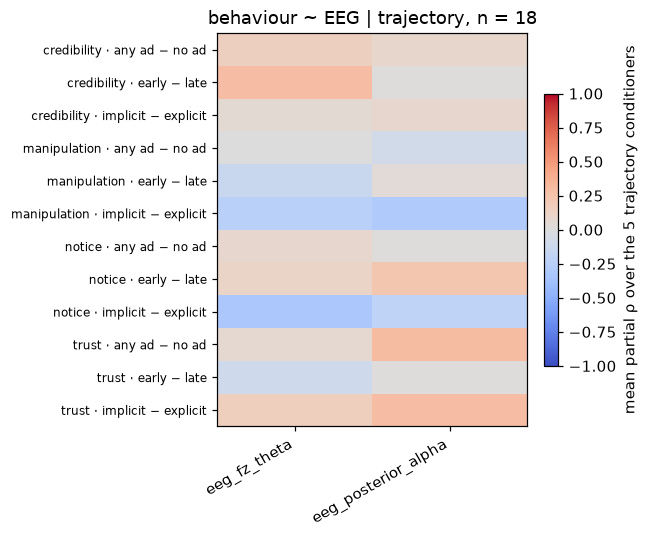

,contrast_label,beh,eeg,traj,n,effect,p_raw,p_holm_family
38,early − late,credibility,eeg_fz_theta,traj_shift_rate,18.0,0.3543,0.1629,1.0
39,implicit − explicit,notice,eeg_fz_theta,traj_entropy_nats,18.0,-0.3453,0.1746,1.0
43,early − late,credibility,eeg_fz_theta,traj_n_shift,18.0,0.3280,0.1986,1.0
44,implicit − explicit,notice,eeg_fz_theta,traj_diversity,18.0,-0.3275,0.1994,1.0
49,any ad − no ad,trust,eeg_posterior_alpha,traj_n_shift,18.0,0.3177,0.2140,1.0
51,implicit − explicit,notice,eeg_fz_theta,traj_max_persistence,18.0,-0.3145,0.2189,1.0
54,implicit − explicit,notice,eeg_fz_theta,traj_shift_rate,18.0,-0.3134,0.2206,1.0
56,any ad − no ad,trust,eeg_posterior_alpha,traj_max_persistence,18.0,0.3122,0.2225,1.0
57,implicit − explicit,manipulation,eeg_posterior_alpha,traj_entropy_nats,18.0,-0.3111,0.2241,1.0
58,implicit − explicit,notice,eeg_fz_theta,traj_n_shift,18.0,-0.3109,0.2246,1.0


In [2]:
sub = t[t.kind == "beh~eeg|traj"]
piv = sub.pivot_table(index=["beh", "contrast_label"], columns="eeg", values="effect", aggfunc="mean")
fig, ax = plt.subplots(figsize=(6, 5)); im = ax.imshow(piv.to_numpy(dtype=float), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(piv.shape[1]), piv.columns, rotation=30, ha="right"); ax.set_yticks(range(piv.shape[0]), [f"{a} · {b}" for a, b in piv.index], fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.04, label="mean partial ρ over the 5 trajectory conditioners"); ax.set_title("behaviour ~ EEG | trajectory, n = 18"); fig.tight_layout(); display(fig); plt.close()
display(sub.sort_values("p_raw").head(10)[["contrast_label", "beh", "eeg", "traj", "n", "effect", "p_raw", "p_holm_family"]].round(4))

## 2. Does trajectory explain anything once EEG is held? (behaviour ~ trajectory | EEG)

The one cluster with raw p ≈ .01: notice any-ad ~ trajectory wandering, holding either EEG feature. That is behaviour × trajectory with EEG held, not an EEG finding, and Holm is .32.

,contrast_label,beh,traj,eeg,n,effect,p_raw,p_holm_family,p_bh_global
0,any ad − no ad,notice,traj_diversity,eeg_posterior_alpha,18.0,0.6190,0.0081,0.3226,0.8962
1,any ad − no ad,notice,traj_diversity,eeg_fz_theta,18.0,0.6176,0.0082,0.3226,0.8962
2,any ad − no ad,notice,traj_entropy_nats,eeg_posterior_alpha,18.0,0.6014,0.0107,0.4048,0.8962
3,any ad − no ad,notice,traj_entropy_nats,eeg_fz_theta,18.0,0.6001,0.0109,0.4048,0.8962
4,early − late,credibility,traj_shift_rate,eeg_fz_theta,18.0,-0.5968,0.0114,0.4574,0.8962
5,any ad − no ad,notice,traj_max_persistence,eeg_fz_theta,18.0,-0.5944,0.0119,0.4266,0.8962
6,any ad − no ad,notice,traj_shift_rate,eeg_fz_theta,18.0,0.5942,0.0119,0.4266,0.8962
7,any ad − no ad,notice,traj_n_shift,eeg_fz_theta,18.0,0.5930,0.0121,0.4266,0.8962
8,any ad − no ad,notice,traj_max_persistence,eeg_posterior_alpha,18.0,-0.5862,0.0134,0.4420,0.8962
9,any ad − no ad,notice,traj_shift_rate,eeg_posterior_alpha,18.0,0.5829,0.0141,0.4496,0.8962


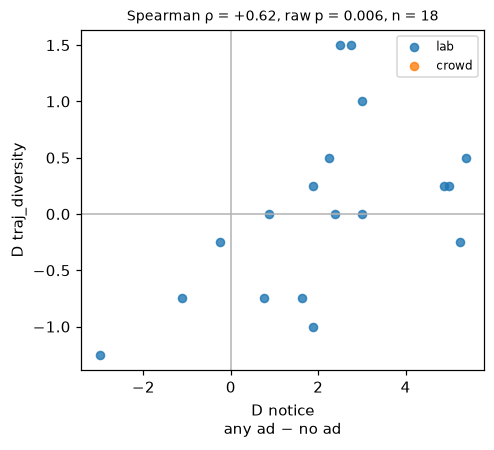

In [3]:
sub = t[t.kind == "beh~traj|eeg"]
display(sub.sort_values("p_raw").head(12)[["contrast_label", "beh", "traj", "eeg", "n", "effect", "p_raw", "p_holm_family", "p_bh_global"]].round(4))
dlab = pd.read_csv(GOLD / "combo_threeway_lab_D.csv")
r = sub.sort_values("p_raw").iloc[0]
display(viz.scatter_D(dlab, r.beh, r.traj, r.contrast)); plt.close()

## 3. All 360 partials

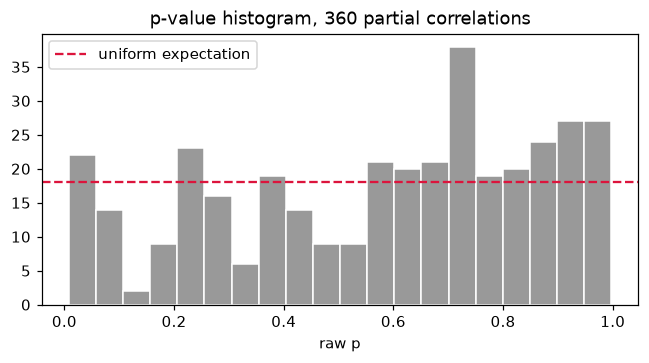

,contrast_label,kind,beh,eeg,traj,n,effect,p_raw,p_holm_family,p_bh_global
0,any ad − no ad,beh~traj|eeg,notice,eeg_posterior_alpha,traj_diversity,18.0,0.6190,0.0081,0.3226,0.8962
1,any ad − no ad,beh~traj|eeg,notice,eeg_fz_theta,traj_diversity,18.0,0.6176,0.0082,0.3226,0.8962
2,any ad − no ad,beh~traj|eeg,notice,eeg_posterior_alpha,traj_entropy_nats,18.0,0.6014,0.0107,0.4048,0.8962
3,any ad − no ad,beh~traj|eeg,notice,eeg_fz_theta,traj_entropy_nats,18.0,0.6001,0.0109,0.4048,0.8962
4,early − late,beh~traj|eeg,credibility,eeg_fz_theta,traj_shift_rate,18.0,-0.5968,0.0114,0.4574,0.8962
5,any ad − no ad,beh~traj|eeg,notice,eeg_fz_theta,traj_max_persistence,18.0,-0.5944,0.0119,0.4266,0.8962
6,any ad − no ad,beh~traj|eeg,notice,eeg_fz_theta,traj_shift_rate,18.0,0.5942,0.0119,0.4266,0.8962
7,any ad − no ad,beh~traj|eeg,notice,eeg_fz_theta,traj_n_shift,18.0,0.5930,0.0121,0.4266,0.8962
8,any ad − no ad,beh~traj|eeg,notice,eeg_posterior_alpha,traj_max_persistence,18.0,-0.5862,0.0134,0.4420,0.8962
9,any ad − no ad,beh~traj|eeg,notice,eeg_posterior_alpha,traj_shift_rate,18.0,0.5829,0.0141,0.4496,0.8962


In [4]:
fig, ax = plt.subplots(figsize=(7, 3.2)); ax.hist(t.p_raw, bins=20, color="0.6", edgecolor="white"); ax.axhline(len(t)/20, color="crimson", ls="--", label="uniform expectation"); ax.set_xlabel("raw p"); ax.legend(); ax.set_title("p-value histogram, 360 partial correlations"); display(fig); plt.close()
t.sort_values("p_raw").head(20)[["contrast_label", "kind", "beh", "eeg", "traj", "n", "effect", "p_raw", "p_holm_family", "p_bh_global"]].round(4)